## 1. Setup and Imports


In [1]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
from ultralytics import YOLO
import torch

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {'GPU' if torch.cuda.is_available() else 'CPU'}")

PyTorch version: 2.9.0
Device: CPU


## 2. Load Trained Multi-Class Model


In [2]:
# Path to best trained model
MODEL_PATH = '/Users/ay/Desktop/deeplearning/Parking lot /Parking-Lot-Occupancy-Estimation-/parking_runs/yolo11m_multiclass/weights/best.pt'
# Load model
model = YOLO(MODEL_PATH)

# Class names
CLASS_NAMES = {
    0: 'car',
    1: 'lot_boundary',
    3: 'stall'
}

print(f"✅ Model loaded: {MODEL_PATH}")
print(f"Classes: {CLASS_NAMES}")

✅ Model loaded: /Users/ay/Desktop/deeplearning/Parking lot /Parking-Lot-Occupancy-Estimation-/parking_runs/yolo11m_multiclass/weights/best.pt
Classes: {0: 'car', 1: 'lot_boundary', 3: 'stall'}


## 3. IoU Calculation Function


In [3]:
def calculate_iou(box1, box2):
    """
    Calculate Intersection over Union (IoU) between two bounding boxes.
    
    Args:
        box1, box2: Bounding boxes in format [x1, y1, x2, y2]
    
    Returns:
        IoU value (0 to 1)
    """
    # Get coordinates
    x1_min, y1_min, x1_max, y1_max = box1
    x2_min, y2_min, x2_max, y2_max = box2
    
    # Calculate intersection area
    inter_x_min = max(x1_min, x2_min)
    inter_y_min = max(y1_min, y2_min)
    inter_x_max = min(x1_max, x2_max)
    inter_y_max = min(y1_max, y2_max)
    
    # Check if there's intersection
    if inter_x_max <= inter_x_min or inter_y_max <= inter_y_min:
        return 0.0
    
    inter_area = (inter_x_max - inter_x_min) * (inter_y_max - inter_y_min)
    
    # Calculate union area
    box1_area = (x1_max - x1_min) * (y1_max - y1_min)
    box2_area = (x2_max - x2_min) * (y2_max - y2_min)
    union_area = box1_area + box2_area - inter_area
    
    # Calculate IoU
    iou = inter_area / union_area if union_area > 0 else 0.0
    
    return iou


def calculate_overlap_ratio(car_box, stall_box):
    """
    Calculate what fraction of the car overlaps with the stall.
    This is more suitable than IoU for occupancy detection.
    
    Args:
        car_box: Car bounding box [x1, y1, x2, y2]
        stall_box: Stall bounding box [x1, y1, x2, y2]
    
    Returns:
        Overlap ratio (0 to 1) - fraction of car inside stall
    """
    x1_min, y1_min, x1_max, y1_max = car_box
    x2_min, y2_min, x2_max, y2_max = stall_box
    
    # Calculate intersection
    inter_x_min = max(x1_min, x2_min)
    inter_y_min = max(y1_min, y2_min)
    inter_x_max = min(x1_max, x2_max)
    inter_y_max = min(y1_max, y2_max)
    
    if inter_x_max <= inter_x_min or inter_y_max <= inter_y_min:
        return 0.0
    
    inter_area = (inter_x_max - inter_x_min) * (inter_y_max - inter_y_min)
    car_area = (x1_max - x1_min) * (y1_max - y1_min)
    
    overlap_ratio = inter_area / car_area if car_area > 0 else 0.0
    
    return overlap_ratio


print("✅ IoU and overlap functions defined")

✅ IoU and overlap functions defined


## 4. Occupancy Detection Function


In [4]:
def detect_occupancy(image_path, conf_threshold=0.25, iou_threshold=0.3):
    """
    Detect parking lot occupancy in an image.
    
    Args:
        image_path: Path to image file
        conf_threshold: Confidence threshold for detections (default 0.25)
        iou_threshold: IoU threshold for matching cars to stalls (default 0.3)
    
    Returns:
        Dictionary containing:
            - cars: List of car detections
            - stalls: List of stall detections
            - occupied_stalls: List of occupied stall indices
            - vacant_stalls: List of vacant stall indices
            - occupancy_rate: Percentage of occupied stalls
    """
    # Run detection
    results = model.predict(source=str(image_path), conf=conf_threshold, verbose=False)
    result = results[0]
    
    # Separate detections by class
    cars = []
    stalls = []
    
    for box in result.boxes:
        cls_id = int(box.cls[0])
        conf = float(box.conf[0])
        xyxy = box.xyxy[0].cpu().numpy()  # [x1, y1, x2, y2]
        
        if cls_id == 0:  # car
            cars.append({
                'bbox': xyxy,
                'conf': conf
            })
        elif cls_id == 3:  # stall
            stalls.append({
                'bbox': xyxy,
                'conf': conf,
                'occupied': False,
                'car_idx': None
            })
    
    # Match cars to stalls using overlap ratio
    occupied_stalls = []
    vacant_stalls = []
    
    for stall_idx, stall in enumerate(stalls):
        max_overlap = 0.0
        matched_car_idx = None
        
        for car_idx, car in enumerate(cars):
            overlap = calculate_overlap_ratio(car['bbox'], stall['bbox'])
            
            if overlap > max_overlap and overlap >= iou_threshold:
                max_overlap = overlap
                matched_car_idx = car_idx
        
        if matched_car_idx is not None:
            stall['occupied'] = True
            stall['car_idx'] = matched_car_idx
            occupied_stalls.append(stall_idx)
        else:
            vacant_stalls.append(stall_idx)
    
    # Calculate occupancy rate
    total_stalls = len(stalls)
    occupied_count = len(occupied_stalls)
    occupancy_rate = (occupied_count / total_stalls * 100) if total_stalls > 0 else 0.0
    
    return {
        'cars': cars,
        'stalls': stalls,
        'occupied_stalls': occupied_stalls,
        'vacant_stalls': vacant_stalls,
        'occupancy_rate': occupancy_rate,
        'total_stalls': total_stalls,
        'occupied_count': occupied_count,
        'vacant_count': len(vacant_stalls)
    }


print("✅ Occupancy detection function defined")

✅ Occupancy detection function defined


## 5. Visualization Function


In [5]:
def visualize_occupancy(image_path, occupancy_data, show_cars=True):
    """
    Visualize parking lot occupancy on image.
    
    Args:
        image_path: Path to image
        occupancy_data: Output from detect_occupancy()
        show_cars: Whether to draw car bounding boxes (default True)
    """
    # Read image
    img = cv2.imread(str(image_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    
    # Create figure
    fig, ax = plt.subplots(1, figsize=(16, 12))
    ax.imshow(img)
    
    # Draw stalls
    for stall_idx, stall in enumerate(occupancy_data['stalls']):
        x1, y1, x2, y2 = stall['bbox']
        width = x2 - x1
        height = y2 - y1
        
        # Color based on occupancy
        if stall['occupied']:
            color = '#FF0000'  # Red for occupied
            label = 'Occupied'
            linewidth = 3
        else:
            color = '#00FF00'  # Green for vacant
            label = 'Vacant'
            linewidth = 3
        
        # Draw rectangle
        rect = plt.Rectangle((x1, y1), width, height,
                            fill=False, edgecolor=color, linewidth=linewidth)
        ax.add_patch(rect)
        
        # Add label
        ax.text(x1 + 5, y1 + 20, label,
               color='white', fontsize=10, weight='bold',
               bbox=dict(boxstyle='round,pad=0.3', facecolor=color, alpha=0.8))
    
    # Draw cars (optional)
    if show_cars:
        for car in occupancy_data['cars']:
            x1, y1, x2, y2 = car['bbox']
            width = x2 - x1
            height = y2 - y1
            
            # Draw car with dashed line
            rect = plt.Rectangle((x1, y1), width, height,
                                fill=False, edgecolor='#FFFF00', 
                                linewidth=2, linestyle='--')
            ax.add_patch(rect)
    
    # Add statistics text
    stats_text = f"Total Stalls: {occupancy_data['total_stalls']}\n"
    stats_text += f"Occupied: {occupancy_data['occupied_count']}\n"
    stats_text += f"Vacant: {occupancy_data['vacant_count']}\n"
    stats_text += f"Occupancy Rate: {occupancy_data['occupancy_rate']:.1f}%"
    
    ax.text(10, 50, stats_text,
           color='white', fontsize=14, weight='bold',
           bbox=dict(boxstyle='round,pad=0.8', facecolor='black', alpha=0.7),
           verticalalignment='top')
    
    ax.axis('off')
    plt.title(f"Occupancy Detection: {os.path.basename(image_path)}", fontsize=16, weight='bold')
    plt.tight_layout()
    plt.show()
    
    # Print summary
    print("\n" + "="*60)
    print(f"📊 {os.path.basename(image_path)}")
    print("="*60)
    print(f"Total Parking Stalls: {occupancy_data['total_stalls']}")
    print(f"Occupied:            {occupancy_data['occupied_count']} ({occupancy_data['occupancy_rate']:.1f}%)")
    print(f"Vacant:              {occupancy_data['vacant_count']} ({100 - occupancy_data['occupancy_rate']:.1f}%)")
    print(f"Cars Detected:       {len(occupancy_data['cars'])}")
    print("="*60 + "\n")


print("✅ Visualization function defined")

✅ Visualization function defined


## 6. Test on Sample Images

Run occupancy detection on test images


Found 7 test images


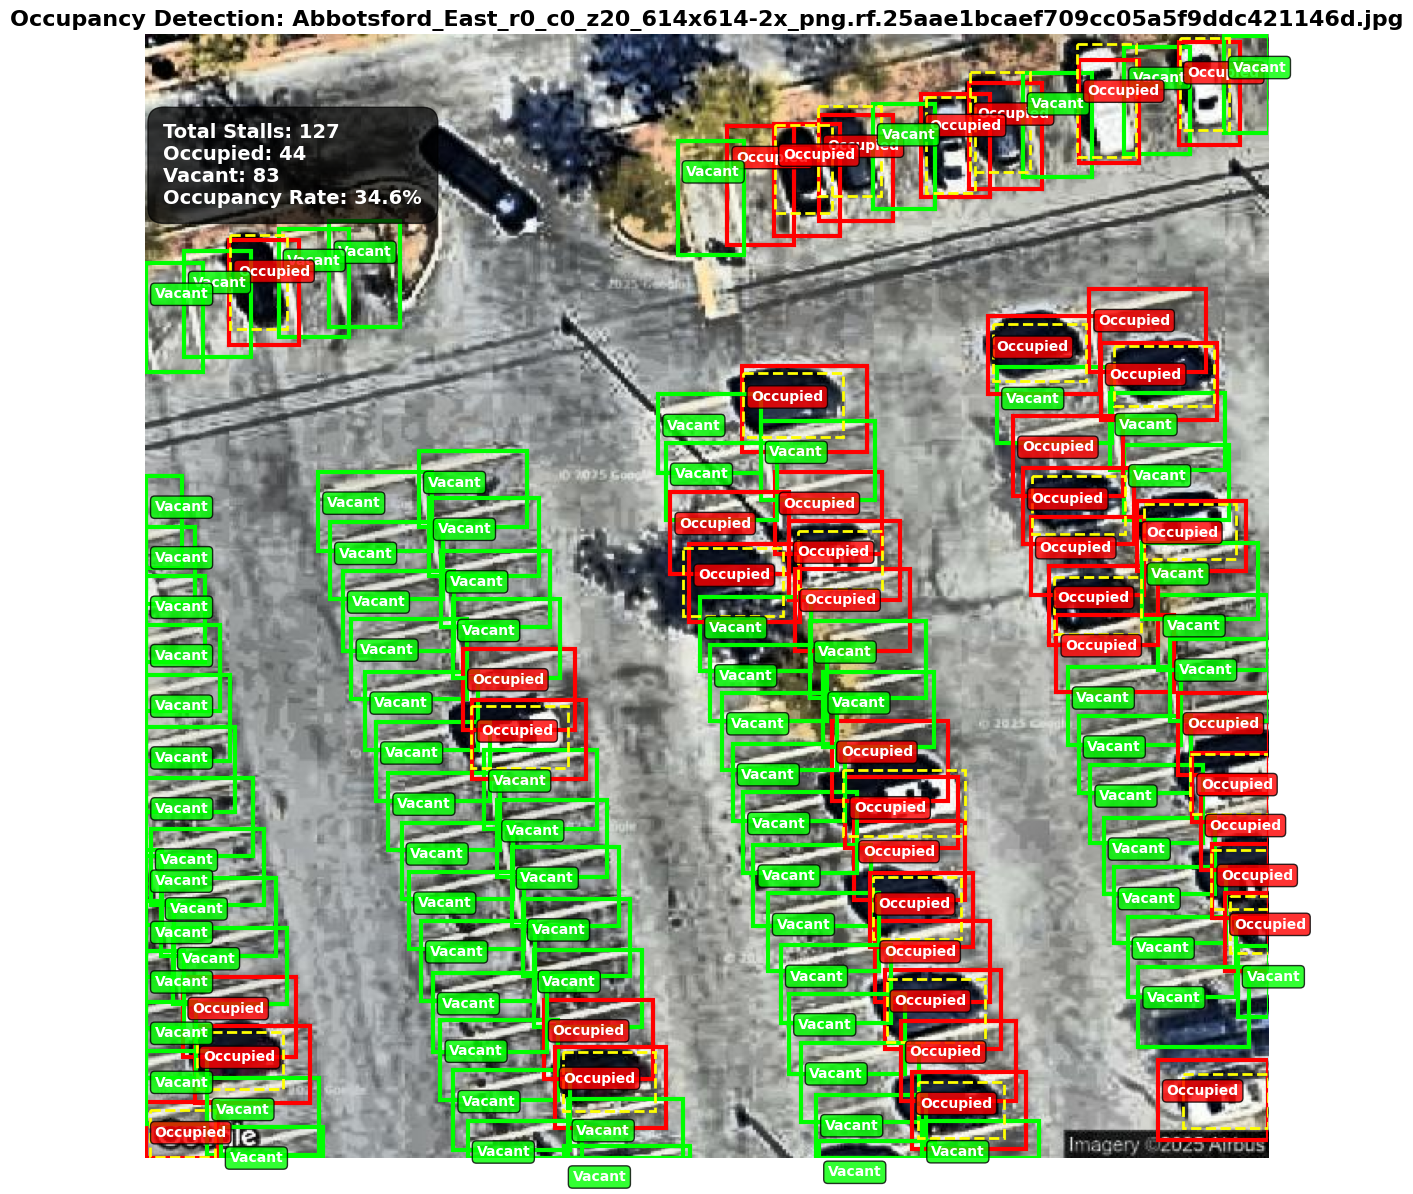


📊 Abbotsford_East_r0_c0_z20_614x614-2x_png.rf.25aae1bcaef709cc05a5f9ddc421146d.jpg
Total Parking Stalls: 127
Occupied:            44 (34.6%)
Vacant:              83 (65.4%)
Cars Detected:       27



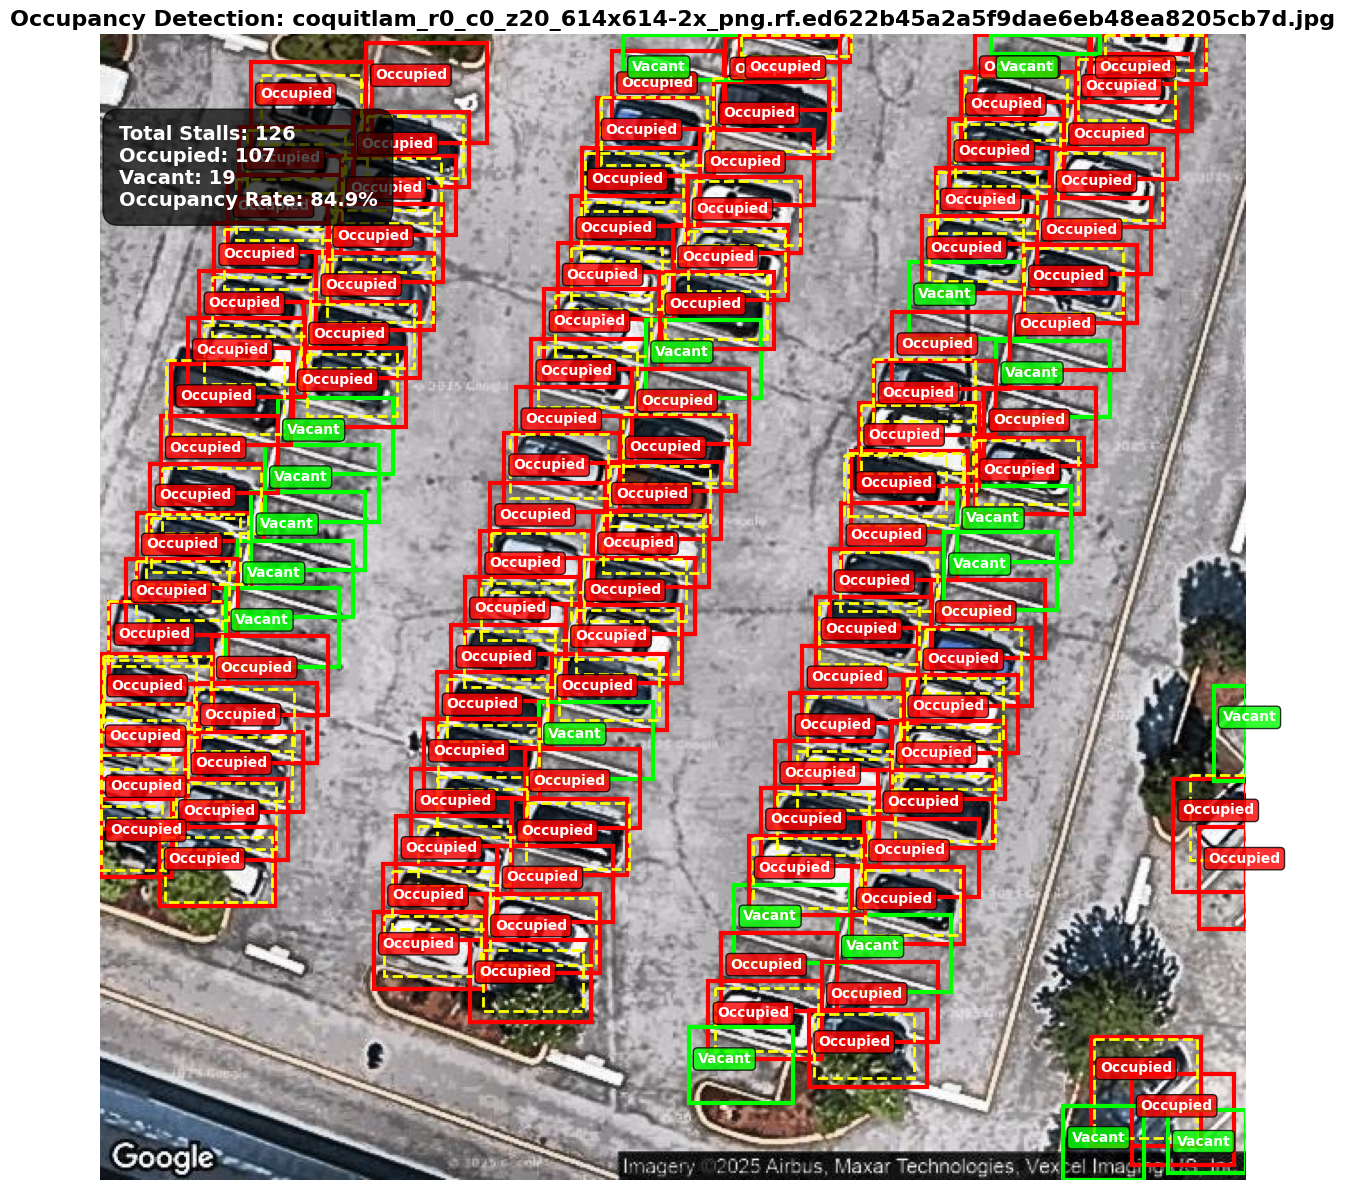


📊 coquitlam_r0_c0_z20_614x614-2x_png.rf.ed622b45a2a5f9dae6eb48ea8205cb7d.jpg
Total Parking Stalls: 126
Occupied:            107 (84.9%)
Vacant:              19 (15.1%)
Cars Detected:       85



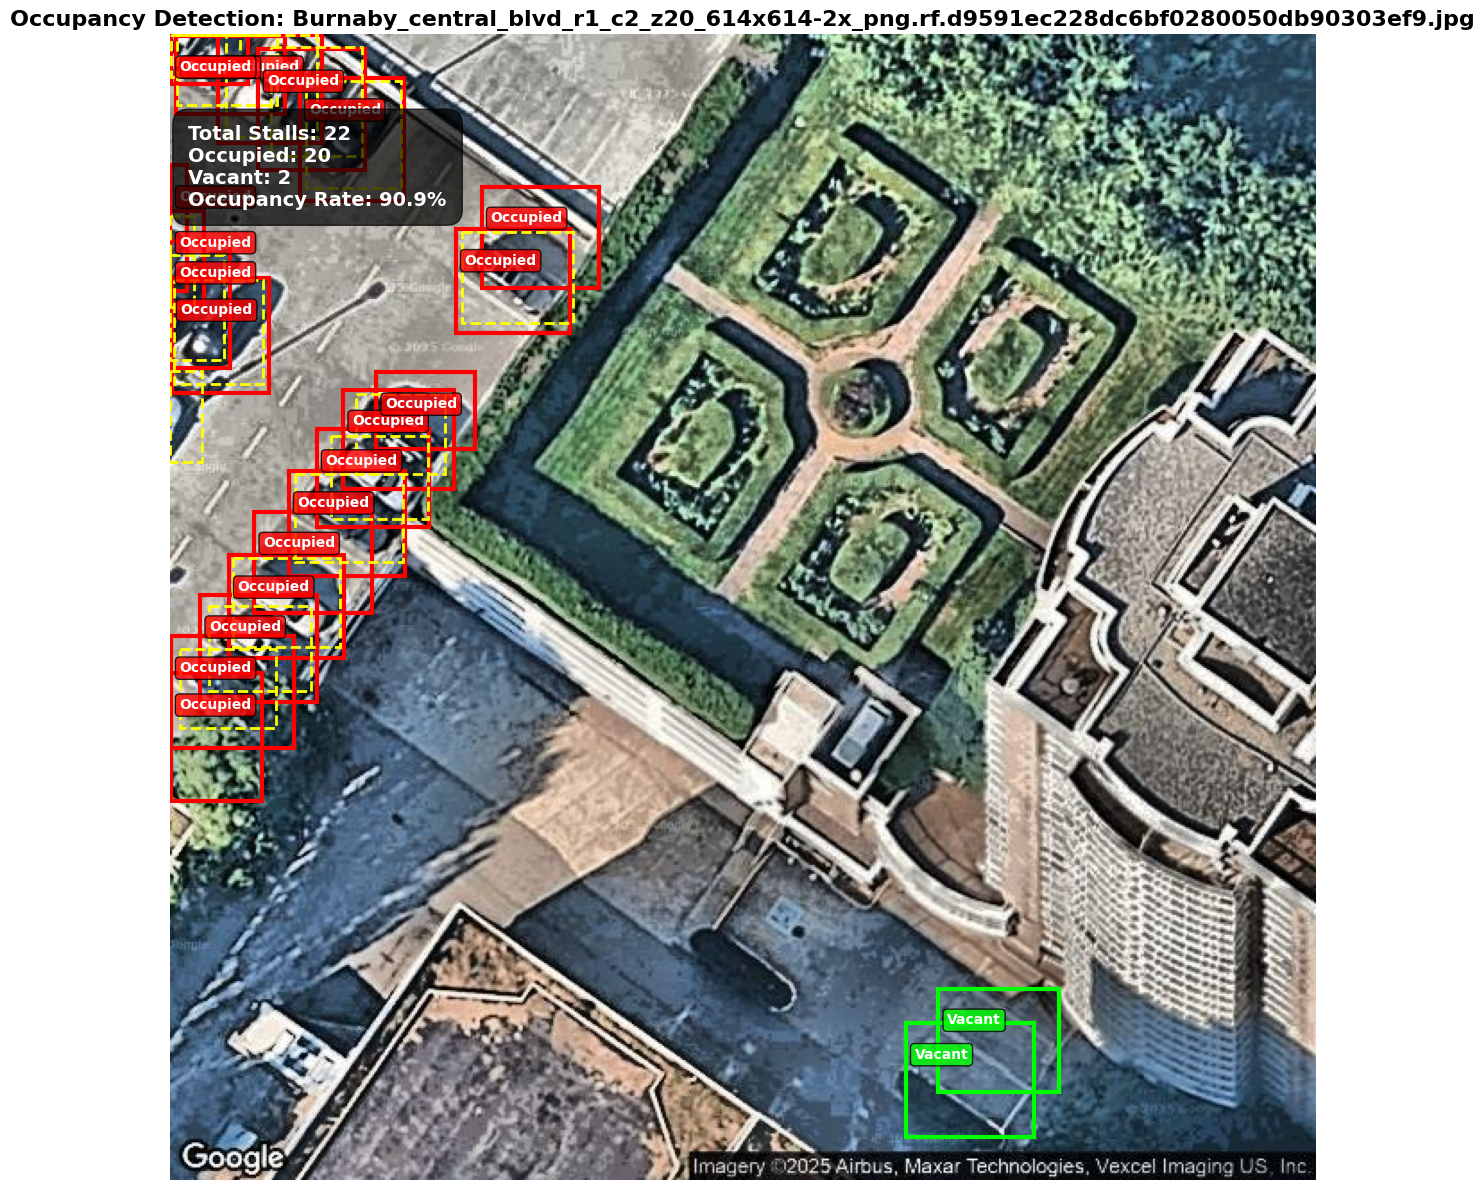


📊 Burnaby_central_blvd_r1_c2_z20_614x614-2x_png.rf.d9591ec228dc6bf0280050db90303ef9.jpg
Total Parking Stalls: 22
Occupied:            20 (90.9%)
Vacant:              2 (9.1%)
Cars Detected:       16



In [6]:
# Get test images from multiclass dataset
test_images_dir = Path("Dataset-V1-multiclass/test/images")

if test_images_dir.exists():
    test_images = list(test_images_dir.glob("*.jpg"))
    print(f"Found {len(test_images)} test images")
else:
    # Fallback to original dataset
    test_images_dir = Path("Dataset-V1-detect/test/images")
    test_images = list(test_images_dir.glob("*.jpg"))[:5]  # First 5
    print(f"Using {len(test_images)} images from Dataset-V1-detect")

# Process first 3 images
for img_path in test_images[:3]:
    # Detect occupancy
    occupancy_data = detect_occupancy(img_path, conf_threshold=0.3, iou_threshold=0.3)
    
    # Visualize results
    visualize_occupancy(img_path, occupancy_data, show_cars=True)

## 7. Batch Processing Function

Process multiple images and collect statistics


In [9]:
def batch_process_images(image_paths, conf_threshold=0.3, iou_threshold=0.5):
    """
    Process multiple images and return aggregated statistics.
    
    Args:
        image_paths: List of image paths
        conf_threshold: Detection confidence threshold
        iou_threshold: IoU threshold for matching
    
    Returns:
        Dictionary with aggregate statistics
    """
    results = []
    
    for img_path in image_paths:
        occupancy_data = detect_occupancy(img_path, conf_threshold, iou_threshold)
        occupancy_data['image_name'] = os.path.basename(img_path)
        results.append(occupancy_data)
    
    # Calculate aggregate statistics
    total_stalls = sum(r['total_stalls'] for r in results)
    total_occupied = sum(r['occupied_count'] for r in results)
    total_vacant = sum(r['vacant_count'] for r in results)
    avg_occupancy = (total_occupied / total_stalls * 100) if total_stalls > 0 else 0.0
    
    aggregate_stats = {
        'num_images': len(image_paths),
        'total_stalls': total_stalls,
        'total_occupied': total_occupied,
        'total_vacant': total_vacant,
        'avg_occupancy_rate': avg_occupancy,
        'individual_results': results
    }
    
    return aggregate_stats


print("✅ Batch processing function defined")

✅ Batch processing function defined


## 8. Process All Test Images


In [10]:
# Process all test images
batch_stats = batch_process_images(test_images, conf_threshold=0.3, iou_threshold=0.3)

# Print aggregate results
print("\n" + "="*70)
print("📊 AGGREGATE STATISTICS FOR ALL TEST IMAGES")
print("="*70)
print(f"Images Processed:      {batch_stats['num_images']}")
print(f"Total Parking Stalls:  {batch_stats['total_stalls']}")
print(f"Total Occupied:        {batch_stats['total_occupied']} ({batch_stats['avg_occupancy_rate']:.1f}%)")
print(f"Total Vacant:          {batch_stats['total_vacant']} ({100 - batch_stats['avg_occupancy_rate']:.1f}%)")
print("="*70)

# Per-image breakdown
print("\n📋 Per-Image Breakdown:")
print("="*70)
for result in batch_stats['individual_results']:
    print(f"{result['image_name']:40s} | Stalls: {result['total_stalls']:2d} | "
          f"Occupied: {result['occupied_count']:2d} | Vacant: {result['vacant_count']:2d} | "
          f"Rate: {result['occupancy_rate']:5.1f}%")
print("="*70)


📊 AGGREGATE STATISTICS FOR ALL TEST IMAGES
Images Processed:      7
Total Parking Stalls:  538
Total Occupied:        233 (43.3%)
Total Vacant:          305 (56.7%)

📋 Per-Image Breakdown:
Abbotsford_East_r0_c0_z20_614x614-2x_png.rf.25aae1bcaef709cc05a5f9ddc421146d.jpg | Stalls: 127 | Occupied: 44 | Vacant: 83 | Rate:  34.6%
coquitlam_r0_c0_z20_614x614-2x_png.rf.ed622b45a2a5f9dae6eb48ea8205cb7d.jpg | Stalls: 126 | Occupied: 107 | Vacant: 19 | Rate:  84.9%
Burnaby_central_blvd_r1_c2_z20_614x614-2x_png.rf.d9591ec228dc6bf0280050db90303ef9.jpg | Stalls: 22 | Occupied: 20 | Vacant:  2 | Rate:  90.9%
surrey_sw_88th_ave_r2_c0_z20_614x614-2x_png.rf.c5a5e0945a271f5c2bd7bd47456e3da3.jpg | Stalls:  5 | Occupied:  2 | Vacant:  3 | Rate:  40.0%
Port_Coquitlam_Hawkins_st_r0_c0_z20_614x614-2x_png.rf.285342836fd679923c706fa0cb90ae44.jpg | Stalls: 48 | Occupied:  6 | Vacant: 42 | Rate:  12.5%
Port_Coquitlam_Hawkins_st_r1_c2_z20_614x614-2x_png.rf.5f64bc31e53388f2dd9dbae1bbe2d8db.jpg | Stalls: 127 | Occ

## 9. Test on Custom Image (Optional)

Test occupancy detection on your own image


In [ ]:
# Uncomment and modify the path below to test on your own image
# custom_image = "path/to/your/parking_lot_image.jpg"
# occupancy_data = detect_occupancy(custom_image, conf_threshold=0.3, iou_threshold=0.3)
# visualize_occupancy(custom_image, occupancy_data, show_cars=True)

print("To test on a custom image, uncomment the code above and set the path")

## 10. Save Results to File (Optional)


In [ ]:
import json

# Save batch statistics to JSON
output_file = "occupancy_results.json"

# Convert numpy arrays to lists for JSON serialization
def serialize_results(data):
    serialized = data.copy()
    for result in serialized['individual_results']:
        for car in result['cars']:
            car['bbox'] = car['bbox'].tolist()
        for stall in result['stalls']:
            stall['bbox'] = stall['bbox'].tolist()
    return serialized

serialized_stats = serialize_results(batch_stats)

with open(output_file, 'w') as f:
    json.dump(serialized_stats, f, indent=2)

print(f"✅ Results saved to: {output_file}")

## Summary

**Occupancy Detection Pipeline:**

1. ✅ Load trained multi-class YOLOv11m model (96.2% mAP50)
2. ✅ Detect cars and stalls in images
3. ✅ Match cars to stalls using IoU overlap
4. ✅ Calculate occupancy statistics
5. ✅ Visualize results with color coding

**Key Features:**

- Green boxes = Vacant stalls
- Red boxes = Occupied stalls
- Yellow dashed boxes = Detected cars
- Real-time occupancy rate calculation
- Batch processing for multiple images

**Adjustable Parameters:**

- `conf_threshold`: Detection confidence (default 0.3)
- `iou_threshold`: Overlap threshold for matching (default 0.3)

**Next Steps:**

- Deploy on real-time camera feeds
- Create web dashboard for monitoring
- Add temporal tracking across video frames
